In [2]:
import pandas as pd
import numpy as np
import re
from scripts import mcmc
from scripts import stability_analysis
from scripts import fem_vis
from scripts import fem_solve
from scripts import noisy_mcmc

import matplotlib
matplotlib.use('QtAgg')
%matplotlib inline
import matplotlib.pyplot as plt

NUM = re.compile(r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?")

In [2]:
x0 = np.array([9.71851258, 127.23060036, 11.02606533, 14.4991172,
               15.65917039, 124.90989748, 123.52196735])
noisy_mcmc.noisy_plots(x0, "results/08_17_2026_NM_results/nm_results_3/stability.csv",
    save_prefix="results/08_17_2026_NM_results/nm_results_3/sweep")

[main] 20 perturbed geometries from results/08_17_2026_NM_results/nm_results_3/stability.csv
[sweep] 21 geometries x 16 positions = 336 FEM solves, submitted as one batch
[sweep] done; 0 position(s) failed to solve
[main] wrote results/08_17_2026_NM_results/nm_results_3/sweep_C.png, _Q.png, _nu.png, _all.png
[main] mean C: nominal 0.2334  perturbed 0.1257 +/- 0.0164


{'nominal': {'x_mm': array([0.        , 0.58333333, 1.16666667, 1.75      , 2.33333333,
         2.91666667, 3.5       , 4.08333333, 4.66666667, 5.25      ,
         5.83333333, 6.41666667, 7.        , 7.58333333, 8.16666667,
         8.75      ]),
  'C': array([0.37105902, 0.23667071, 0.2330799 , 0.23939936, 0.24837473,
         0.26162314, 0.27442065, 0.25838406, 0.20796592, 0.23545817,
         0.16136705, 0.21972405, 0.23293503, 0.21489044, 0.18633831,
         0.1529523 ]),
  'Q': array([ 7564.34368725,  8019.5063601 ,  7925.25799399,  8130.33945011,
          8346.90848395,  8562.98942945,  8799.39267808,  9326.86483445,
          9879.43002163,  9729.91717593,  9885.21632451,  9794.55192544,
          9961.6863728 , 10161.95637466, 10381.58117933, 10618.71413761]),
  'f': array([1.50432250e+10, 1.41846163e+10, 1.34634190e+10, 1.28032138e+10,
         1.22047942e+10, 1.16609732e+10, 1.11658991e+10, 1.07211368e+10,
         1.03060491e+10, 9.88435510e+09, 9.51406439e+09, 9.1992297

In [ ]:
n = 10
df = pd.read_csv("results/08_13_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

best = np.argsort(values_arr)
tn_params = params_arr[best][:n]

refined = []
for i, params_mm in enumerate(tn_params):
    refined.append(mcmc.NM_opt(params_mm,500,save_path='./results/08_17_2026_NM_results/', csv_name=f'nm_evals_{i}.csv'))

print(refined)

In [ ]:
df = pd.read_csv("results/08_13_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

# ignore the 1e+33 values
ignore_args = np.where(values_arr!=1e+33)
values_arr = values_arr[ignore_args]
wid_arr = wid_arr[ignore_args]
params_arr = params_arr[ignore_args]

#print(values_arr)
#print(params_arr)

print(np.mean(np.log(values_arr)))
print(np.std(np.log(values_arr)))

In [ ]:
# sort by where theta is
small_theta_args = np.where(theta_vals<=15)
large_theta_args = np.where(theta_vals>15)
gap_1_small_theta = gap1_vals[small_theta_args]
gap_1_large_theta = gap1_vals[large_theta_args]
small_theta_values = values_arr[small_theta_args]
large_theta_values = values_arr[large_theta_args]

fig,ax=plt.subplots()
ax.scatter(gap_1_small_theta, np.log(small_theta_values), marker='.', c='b', alpha=0.5)
#ax.scatter(gap_1_large_theta, np.log(large_theta_values), marker='.', c='b', alpha=0.5)
ax.set_ylabel('Log objective')
ax.set_xlabel('gap1 (mm)')
ax.set_title('Log objective vs gap1, $\\theta\\leq15^\\circ$')
plt.show()

In [ ]:
fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    #gap1_vals_wid = gap1_vals[walker_id_args]
    values_wid = values_arr[walker_id_args]
    print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    #ax_flat[walker_id].scatter(gap1_vals_wid, np.log(values_wid), marker='.', c='b')
plt.tight_layout()
plt.show()

In [ ]:
best = np.argsort(values_arr)
t10_params = params_arr[best][:10]
print(values_arr[best][:10])
print(t10_params)

best_params = params_arr[best][0]
print(best_params)
#print(mcmc.fom(best_params, verbose=True))

In [ ]:
param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2,4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

In [3]:
df_all = pd.read_csv('results/08_04_2026_mcmc_results/all_params_all_values.csv')
params_all = df_all['Parameters']
values_all = df_all['Value']
wid_all = df_all['Walker']
params_arr_all = []
values_arr_all = []
wid_arr_all = []

for i, param in enumerate(params_all):
    params_arr_all.append(mcmc._parse_params(param, n_params=8))
    values_arr_all.append(values_all.loc[i])
    wid_arr_all.append(wid_all.loc[i])

params_arr_all = np.asarray(params_arr_all)
values_arr_all = np.asarray(values_arr_all)
wid_arr_all = np.asarray(wid_arr_all)

ignore_args_all = np.where(values_arr_all!=1e+33)
values_arr_all = values_arr_all[ignore_args_all]
wid_arr_all = wid_arr_all[ignore_args_all]
params_arr_all = params_arr_all[ignore_args_all]

param_names = ['theta', 'div_height', 'div_width', 'gap1', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel(r"$\log(\mathrm{objective})$")

plt.tight_layout()
plt.show()

C:\Users\bingk\AppData\Local\Temp\ipykernel_26260\522142974.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
best = np.argsort(values_arr_all)
print(np.unique(values_arr_all[best]))
#print(params_arr_all[best])

i = 0
curr_ind = 0
tn_best = []
while i < 10:
    if list(params_arr_all[best][curr_ind]) not in tn_best:
        tn_best.append(list(params_arr_all[best][curr_ind]))
        i += 1
        curr_ind += 1
    else:
        curr_ind += 1

print(np.asarray(tn_best))

[1.71193036e+31 1.75698905e+31 1.82456728e+31 ... 1.66474849e+32
 2.01147738e+32 2.03814980e+32]
[[6.64824190e-01 1.20250169e+02 3.33057059e+00 1.00067577e+01
  1.11888175e+01 1.05143685e+01 1.13177544e+02 1.20734733e+02]
 [5.79408710e-01 1.22436327e+02 3.62519767e+00 1.00144176e+01
  1.21676561e+01 1.15180021e+01 1.13645286e+02 1.16767193e+02]
 [0.00000000e+00 1.25000000e+02 5.00000000e+00 1.00000000e+01
  6.00000000e+00 6.00000000e+00 1.25000000e+02 1.25000000e+02]
 [4.48810118e+00 1.02331021e+02 6.95755156e+00 9.99361911e+00
  6.52889607e+00 5.48652203e+00 1.23439131e+02 1.09029950e+02]
 [2.15071150e+00 1.26888987e+02 3.86425822e+00 9.99599015e+00
  7.78336221e+00 6.89821831e+00 1.19565251e+02 1.24570527e+02]
 [7.11741696e-12 1.19014362e+02 9.66898137e+00 1.00140326e+01
  7.41924722e+00 7.47538978e+00 1.11352896e+02 1.22267389e+02]
 [3.78865122e+00 1.09935855e+02 6.56418539e+00 1.00057126e+01
  6.25374128e+00 5.47552628e+00 1.16901595e+02 1.13785297e+02]
 [1.19772613e-12 1.13267965e

In [ ]:
# best so far plot

best_so_far = np.minimum.accumulate(values_arr_all)
fig, ax = plt.subplots()
ax.plot(np.linspace(1, len(best_so_far), len(best_so_far)), np.log(best_so_far))
ax.set_xlabel('Iteration')
ax.set_ylabel('Log objective')

In [ ]:
probs = df["AcceptProb"]
fig, ax = plt.subplots()
ax.scatter(probs[-np.isnan(df["AcceptProb"])].index, probs[-np.isnan(df["AcceptProb"])], marker='.', c='b')

probs = np.asarray(probs)
wid_arr = np.asarray(wid)

fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    probs_wid = probs[walker_id_args]
    probs_wid = probs_wid[~np.isnan(probs_wid)]
    inds = np.linspace(10, len(probs_wid)-10, len(probs_wid))
    #print(len(inds))
    #print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(inds, probs_wid, marker='.', c='b')
    ax_flat[walker_id].set_title(f'Walker {walker_id}')
    ax_flat[walker_id].set_xlabel('Iteration')
    ax_flat[walker_id].set_ylabel('Probability')

print(len(inds))
plt.tight_layout()
plt.show()


range for div_height: [np.float64(102.3310211), np.float64(133.448459)]
range for div_width: [np.float64(3.33057059), np.float64(9.66898137)]
range for gap1: [np.float64(9.99361911), np.float64(10.01441757)]
range for center_width: [np.float64(4.34569752), np.float64(13.2899712)]
range for side_width: [np.float64(5.08616114), np.float64(14.3832584)]
range for center_height: [np.float64(111.352896), np.float64(131.881129)]
range for side_height: [np.float64(109.0299504), np.float64(125.0)]


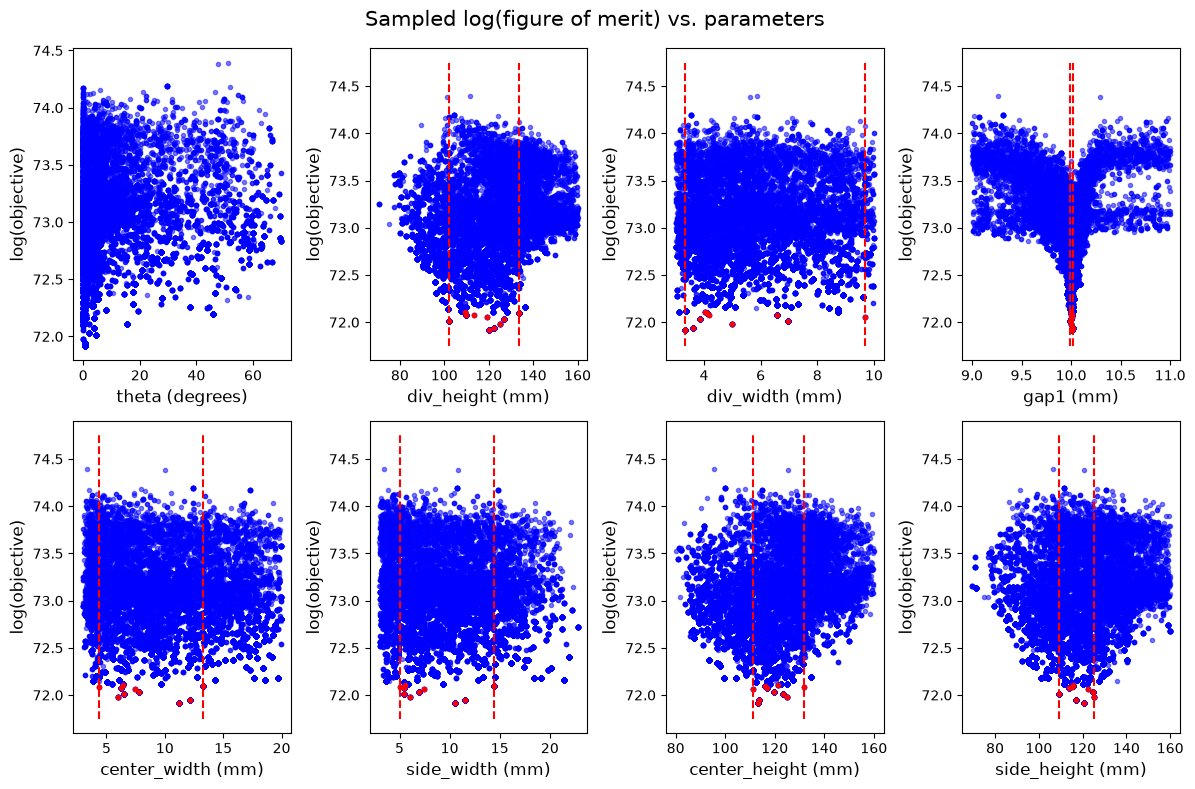

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

n = 10
#tn_params = params_arr[best][:n]
tn_params = np.asarray(tn_best)

for i, name in enumerate(param_names):
    #print(f'optimal {name}s: {t10_params[:,i]}\n')
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.', alpha=0.5)
    if name == 'theta':
        ax_flat[i].set_xlabel(name + ' (degrees)', fontsize='large')
    else:
        ax_flat[i].set_xlabel(name + ' (mm)', fontsize='large')
    ax_flat[i].set_ylabel(r"$\log(\mathrm{objective})$", fontsize='large')
    if i != 0:
        ax_flat[i].vlines([np.min(tn_params[:,i]), np.max(tn_params[:,i])], 71.75, 74.75, colors='r', ls='--')
        print(f'range for {name}: {[np.min(tn_params[:,i]), np.max(tn_params[:,i])]}')
        ax_flat[i].scatter(tn_params[:,i], np.log(np.unique(values_arr_all[best])[:n]), c='r', marker='.')

plt.suptitle(r"Sampled $\log(\text{figure of merit})$ vs. parameters", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
print(mcmc.fom([43.08239729, 128.44919526, 5.33452249, 9.99969355, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))
print()
print(mcmc.fom([0, 128.44919526, 5.33452249, 10, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))


In [ ]:
# stability analysis
path = "results/08_17_2026_NM_results"

def get_best(name):
    df = pd.read_csv(name)
    best_params = mcmc._parse_params(df['Parameters'][np.argmin(df['Value'])], n_params=7)
    return best_params

for i in range(10):
    name = path+f"/nm_evals_{i}"
    nominal_result, samples, summary=stability_analysis.check_stability(get_best(name), n_samples=20, save_path=path+f"/nm_results_{i}")
#print(summary)
#print(nominal_result, samples, summary)

In [ ]:
x0 = [9.71851258,127.23060036, 11.02606533, 14.4991172 , 15.65917039,124.90989748,123.52196735]
nominal_result, samples, summary = stability_analysis.check_stability(x0, n_samples=12, check_limits=False)

[stability] 33 dimensions, 33 with non-zero sigma
[stability] 12 iid samples x 16 tuning steps = 192 FEM solves
[stability] no tuning-position error: every sample walks the exact nominal trajectory
[noisy] BOUNDS: divL_w = 11.03 >= gap0L = 10 (design rule div_w < gap0 -- note gap0, the gap flanking the CENTRE toast, not gap1; this is not an overlap test, see the geometry severity for those); divR_w = 11.03 >= gap0R = 10 (design rule div_w < gap0 -- note gap0, the gap flanking the CENTRE toast, not gap1; this is not an overlap test, see the geometry severity for those) -> PENALTY  (repeats suppressed; noisy_mcmc.WARN_MODE = 'always' to see them all, report_violations() for the tally)
[stability] nominal: FOM=1e+33  meanC=nan  (0.0s)
  [1/12] FOM=1e+33  minC=nan  gap asym=0.0773 mm  [infeasible]
  [2/12] FOM=1e+33  minC=nan  gap asym=0.2210 mm  [infeasible]
  [3/12] FOM=1e+33  minC=nan  gap asym=0.2646 mm  [infeasible]
  [4/12] FOM=1e+33  minC=nan  gap asym=0.1515 mm  [infeasible]
  [5/1

In [4]:
# stability analysis metrics
path = "results/08_17_2026_NM_results"

def get_best(name):
    df = pd.read_csv(name)
    best_params = mcmc._parse_params(df['Parameters'][np.argmin(df['Value'])], n_params=7)
    best_value = np.min(df['Value'])
    return best_params, best_value

perturbed_factors = []
mean_foms = []
raw_foms = []
raw_params = []
curr_val = np.inf
best_ind = 0

for i in range(10):
    name = path + f"/nm_results_{i}/stability.csv"
    evals_name = path+f"/nm_evals_{i}.csv"
    df = pd.read_csv(name)
    df_evals = pd.read_csv(evals_name)
    best_nm_params, best_nm_value = get_best(evals_name)
    raw_foms.append(best_nm_value)
    raw_params.append(best_nm_params)
    if best_nm_value <= curr_val:
        best_params=best_nm_params
        curr_val = best_nm_value
        best_ind = i
    perturbed_factors.append((best_nm_value, np.mean(df['fom'])/best_nm_value))
    mean_foms.append(np.mean(df['fom']))

print(np.min(np.asarray(mean_foms)), np.argmin(np.asarray(mean_foms)))

5.565947488645413e+31 2


In [ ]:
# metrics for best geometries
raw_foms = np.asarray(raw_foms)
raw_params = np.asarray(raw_params)

sorted_args = np.argsort(raw_foms)
t5_params = raw_params[sorted_args][:5]

for i, params_mm in enumerate(t5_params):
    value, details = mcmc.fom(params_mm, tuning_steps=16, return_details=True)
    print(f'====================RANK {i+1}====================')
    print(f"mean C: {np.mean(details['C'])}, min C: {np.min(details['C'])}")
    print(np.mean(details['Q']))
    print(f"min freq: {np.min(details['f'])}, max freq: {np.max(details['f'])}")
    print(f"best fom: {np.log(value)}")
    print(f"perturbed factor: {perturbed_factors[sorted_args[i]][1]}, mean fom: {np.log(mean_foms[sorted_args[i]])}")
    print("==============================================")

    # make plots for best geometry
        


In [ ]:
# plots for best geometry
params_mm = best_params
params_m = mcmc._params_to_m(params_mm)
specs,results = fem_solve.run_sweep(
    lambda dx, dy, i: mcmc.make_spec(params_mm, toast_dx=dx, toast_dy=dy, tag=f"x={dx*1e3:.2f}mm"),
    mcmc.tuning_positions(params_mm, n=4),        # yields (dx, dy, f_guess) per step
    n_modes=6,
    n_workers=None,            # every core
    timeout=600,               # bad geometry fails instead of stalling
    plot_all=True,          # needed for plot_best_modes
)
entries = [(s, r, f"x={x*1e3:.2f} mm")
            for (x, _y, _f), s, r in zip(mcmc.tuning_positions(params_mm), specs, results)
            if r["ok"]]
fem_vis.plot_best_modes_magnitude_square(entries, save=f'results/best_design.png', ncol=2)

In [5]:
for i, params_mm in enumerate(tn_params): 
    #best_params_mm = np.asarray([7.83871556e+00, 1.26157650e+02, 9.19378470e+00, 1.75440332e+01, 1.85117677e+01, 1.26545044e+02, 1.25794783e+02])
    params_m = mcmc._params_to_m(params_mm)
    spec = fem_vis.toaster_spec(params_m)
    if i == 0:
        fem_vis.plot_spec(spec, save=f'results/08_13_2026_mcmc_results/plots/toaster_geometry_center.png')
    specs,results = fem_solve.run_sweep(
        lambda dx, dy, i: mcmc.make_spec(params_mm, toast_dx=dx, toast_dy=dy, tag=f"x={dx*1e3:.2f}mm"),
        mcmc.tuning_positions(params_mm),        # yields (dx, dy, f_guess) per step
        n_modes=6,
        n_workers=None,            # every core
        timeout=600,               # bad geometry fails instead of stalling
        plot_all=True,          # needed for plot_best_modes
    )
    entries = [(s, r, f"x={x*1e3:.2f} mm")
                for (x, _y, _f), s, r in zip(mcmc.tuning_positions(params_mm), specs, results)
                if r["ok"]]
    fem_vis.plot_best_modes_magnitude_square(entries, save=f'results/08_13_2026_mcmc_results/plots/toaster_tuning_modes_{i+1}.png')

NameError: name 'tn_params' is not defined

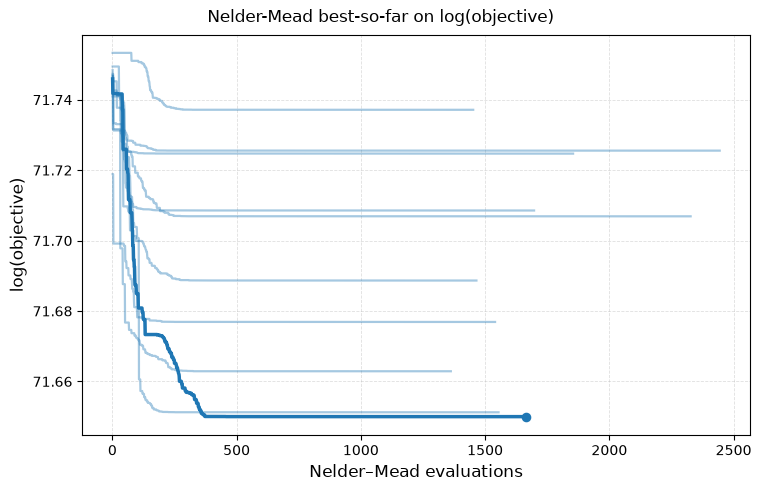

In [13]:
# make best-so-far plots using Nelder-Mead

path = "results/08_17_2026_NM_results/"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)

# Store runs so we can identify the best one
runs = []

for i in range(10):
    fname = path + f"nm_evals_{i}.csv"
    df = pd.read_csv(fname)

    vals = np.asarray(df["Value"])
    best = np.minimum.accumulate(vals)
    x = np.arange(1, len(best) + 1)

    runs.append((i, x, best))

# Find the run with the lowest final objective
best_i, _, best_vals = min(runs, key=lambda r: r[2][-1])

# Plot all runs in the same muted color
for i, x, best in runs:
    if i+1 != 10:
        ax.plot(
            x,
            np.log(best),
            color="C0",
            linewidth=1.6,
            alpha=0.40,
        )
    else:
        ax.plot(
            x,
            np.log(best),
            color="C0",
            linewidth=1.6,
            alpha=0.40,
        )

# Highlight the best run
best_x = runs[best_i][1]
ax.plot(
    best_x,
    np.log(best_vals),
    color="C0",
    linewidth=2.5,
    alpha=1.0,
)

# Mark the final point of the best run
ax.scatter(
    best_x[-1],
    np.log(best_vals[-1]),
    color="C0",
    s=35,
    zorder=3,
)

ax.set_xlabel("Nelder–Mead evaluations", fontsize='large')
ax.set_ylabel(r"$\log(\mathrm{objective})$", fontsize='large')

# Light grid
ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Clean up the frame
#ax.spines["top"].set_visible(False)
#ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

# Small padding around the data
#ax.margins(x=0.02, y=0.05)

# Only identify the highlighted run
#ax.legend(
#    frameon=False,
#    fontsize=9,
#    loc="best",
#)

plt.suptitle(r'Nelder-Mead best-so-far on $\log(\text{objective})$')

plt.show()